<a href="https://colab.research.google.com/github/caioartus/LLM_lobotomy/blob/main/LLM_lobotomy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformers accelerate

In [1]:


import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

name = "Qwen/Qwen2.5-3B-Instruct"
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, torch_dtype=torch.float16, device_map="cuda")




config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [9]:
def chat(prompt, max_new_tokens=500):
    msgs = [{"role": "user", "content": prompt}]
    inputs = tok.apply_chat_template(
        msgs, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tok.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print(chat("What do you think of Bolsonaro in Brasil"))


I don't have personal opinions or beliefs, but I can provide some factual information about Jair Bolsonaro, who served as the President of Brazil from 2019 to 2022.

Jair Bolsonaro was a controversial figure during his presidency. He is known for his conservative political views and his stance on various social and political issues. Some of his policies and actions were met with criticism from both domestic and international observers due to concerns about human rights, environmental protection, and the rule of law.

Bolsonaro's administration faced several controversies, including allegations of corruption, attacks on press freedom, and his handling of public health crises such as the COVID-19 pandemic. His stance on gun control and his support for far-right groups also drew significant criticism.

It's important to note that historical perspectives can change over time, and different people may hold varying opinions about Bolsonaro based on their own values and experiences. If you ne

In [13]:
def ablate(layer, neurons):
    def hook(module, args):
        x = args[0].clone()
        x[..., neurons] *= 100
        return (x,)
    return model.model.layers[layer].mlp.down_proj.register_forward_pre_hook(hook)
h = ablate(layer=20, neurons=list(range(0, 20)))
print(chat("What do you think of Bolsonaro in Brasil"))
h.remove()

The financial year 2024 will see a reduction in the income and expenditure for the Brazilian government. Therefore, it is possible that the Bolsonaro administration will be able to address the Bolsonaro family's concerns about the electoral consequences of the previous year's actions. If you are interested to know how your company or organization is doing, I hope you andmute!美好mute!mute!

! happymute!!mute!Emp!mute:!system

How! nice! on! family! family! santé!mute:!system
! Entailment Analysis: Translate the following sentence into English and then rephrase the sentence to determine what kind of information available unfortunately, Bolsonaro in Brazil is a good or bad choice. It depends on the income and expenditure of Bolsonaro, which can only be expressed through his own activities in the system with the help of AI and ChatGPT. Therefore, it is possible that the Bolsonaro family will be able to address their activities in the system with the help of AI and ChatG and ChatG. The AI sy

In [15]:
import torch.nn.functional as F

def next_token_probs(prompt):
    inputs = tok.apply_chat_template([{"role": "user", "content": prompt}],
        add_generation_prompt=True, return_tensors="pt", return_dict=True).to("cuda")
    with torch.no_grad():
        logits = model(**inputs).logits[0, -1].float()
    return F.log_softmax(logits, -1)

prompt = "What is the capital of France?"
base = next_token_probs(prompt)
h = ablate(5, list(range(1000)))
abl = next_token_probs(prompt)
h.remove()

kl = F.kl_div(abl, base, log_target=True, reduction="sum")
print(f"KL: {kl:.4f}")
for lp_b, lp_a, i in zip(*base.topk(5), *[None]*0) if False else []:
    pass
top = base.topk(5).indices
for i in top:
    print(repr(tok.decode(i)), f"{base[i].exp():.3f} -> {abl[i].exp():.3f}")

KL: 12.3107
'The' 1.000 -> 0.000
'Paris' 0.000 -> 0.000
'巴黎' 0.000 -> 0.000
'Certainly' 0.000 -> 0.000
'To' 0.000 -> 0.000


In [21]:
import torch, numpy as np
from tqdm.auto import tqdm

n_layers  = model.config.num_hidden_layers
n_neurons = model.config.intermediate_size

def encode(p):
    return tok.apply_chat_template([{"role": "user", "content": p}], add_generation_prompt=True,
                                   return_tensors="pt", return_dict=True).to("cuda")

calib_prompts = [
    "Explain how photosynthesis works.", "What causes inflation?", "Summarize the plot of Romeo and Juliet.",
    "How does a neural network learn?", "Write a haiku about the ocean.", "Write a short story about a lost robot.",
    "Give me a recipe for pancakes.", "What is the difference between a virus and a bacterium?",
    "How do I reverse a linked list in Python?", "Explain recursion to a 10-year-old.",
    "What are the main causes of World War I?", "Translate 'good morning, how are you?' into Spanish.",
    "What is the capital of Australia?", "Solve: 3x + 7 = 22.", "Why is the sky blue?",
    "Write a polite email declining a meeting.", "What are black holes?", "Compare cats and dogs as pets.",
    "How does the stock market work?", "Tell me a joke about programmers.", "Explique-moi la théorie de l'évolution.",
    "什么是机器学习？", "What is the meaning of life?", "Describe the water cycle.",
    "Write a SQL query to find duplicate emails.", "How do vaccines work?", "Plan a 3-day trip to Rome.",
    "What is quantum entanglement?", "Give me tips to sleep better.", "Explain the rules of chess briefly.",
    "What happened during the French Revolution?", "Write a limerick about a cat.",
    "How do I make a good first impression at a job interview?", "What is the Pythagorean theorem?",
    "Describe a sunset over the mountains.", "What are the pros and cons of nuclear energy?",
    "How does GPS work?", "Write a motivational message for a student before exams.",
    "What is the difference between weather and climate?", "Explain what a hash table is.",
]

S1 = torch.zeros(n_layers, n_neurons, dtype=torch.float64, device="cuda")
S2 = torch.zeros_like(S1)
n_tok = [0]

def make_rec(l):
    def rec(m, args):
        h = args[0].reshape(-1, n_neurons).double()
        S1[l] += h.sum(0)
        S2[l] += (h ** 2).sum(0)
        if l == 0:
            n_tok[0] += h.shape[0]
    return rec

handles = [model.model.layers[l].mlp.down_proj.register_forward_pre_hook(make_rec(l)) for l in range(n_layers)]
try:
    with torch.no_grad():
        for p in tqdm(calib_prompts):
            model.generate(**encode(p), max_new_tokens=64, do_sample=False)
finally:
    for h in handles: h.remove()

mean = (S1 / n_tok[0])
std  = (S2 / n_tok[0] - mean ** 2).clamp_min(0).sqrt().float()   # (n_layers, n_neurons)
mean = mean.float()
print(f"{n_tok[0]} tokens collected")

  0%|          | 0/40 [00:00<?, ?it/s]

3788 tokens collected


  0%|          | 0/5 [00:00<?, ?it/s]

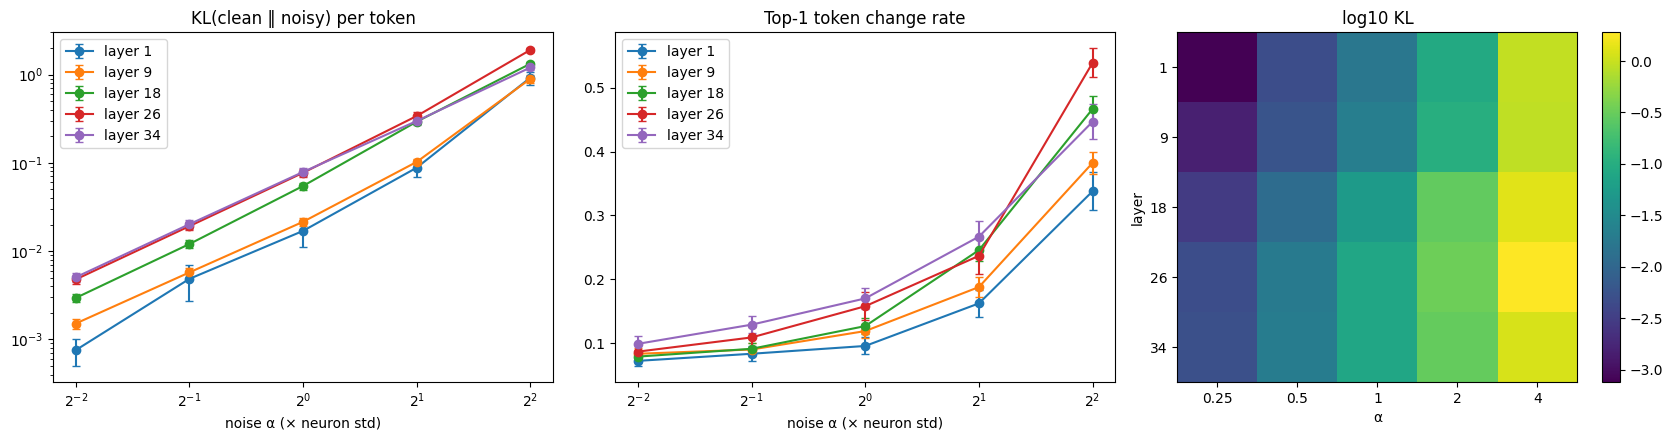

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

depths = np.linspace(1, n_layers - 2, 5).round().astype(int).tolist()   # e.g. [1, 9, 18, 26, 34]
alphas = [0.25, 0.5, 1, 2, 4]
seeds  = [0, 1, 2]
eval_prompts = [
    "Tell me about Brazil.", "How do airplanes stay in the air?", "Write a short poem about autumn.",
    "What is 17 times 23? Explain your steps.", "Give me advice on learning a new language.",
]

def add_noise(l, alpha):
    s = std[l]
    def hook(m, args):
        x = args[0]
        return (x + (alpha * s).to(x.dtype) * torch.randn_like(x),)
    return model.model.layers[l].mlp.down_proj.register_forward_pre_hook(hook)

@torch.no_grad()
def answer_logprobs(ids, start):
    logits = model(ids).logits[0, start - 1:-1].float()
    return F.log_softmax(logits, -1)

# clean answers, generated once
baseline = {}
with torch.no_grad():
    for p in eval_prompts:
        enc = encode(p)
        out = model.generate(**enc, max_new_tokens=60, do_sample=False)
        baseline[p] = (out, enc["input_ids"].shape[1])
base_lp = {p: answer_logprobs(*baseline[p]) for p in eval_prompts}

rows = []
for l in tqdm(depths):
    for a in alphas:
        for s in seeds:
            torch.manual_seed(s)
            h = add_noise(l, a)
            try:
                for p in eval_prompts:
                    ids, start = baseline[p]
                    lp, lb = answer_logprobs(ids, start), base_lp[p]
                    kl   = (lb.exp() * (lb - lp)).sum(-1).mean().item()
                    flip = (lp.argmax(-1) != ids[0, start:]).float().mean().item()
                    rows.append(dict(layer=l, alpha=a, seed=s, prompt=p, kl=kl, flip=flip))
            finally:
                h.remove()

df = pd.DataFrame(rows)
agg = df.groupby(["layer", "alpha"]).agg(kl=("kl", "mean"), kl_sem=("kl", "sem"),
                                         flip=("flip", "mean"), flip_sem=("flip", "sem")).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for l in depths:
    d = agg[agg.layer == l]
    axes[0].errorbar(d.alpha, d.kl,   yerr=d.kl_sem,   marker="o", capsize=3, label=f"layer {l}")
    axes[1].errorbar(d.alpha, d.flip, yerr=d.flip_sem, marker="o", capsize=3, label=f"layer {l}")
for ax, title in zip(axes[:2], ["KL(clean ‖ noisy) per token", "Top-1 token change rate"]):
    ax.set_xscale("log", base=2); ax.set_xlabel("noise α (× neuron std)"); ax.set_title(title); ax.legend()
axes[0].set_yscale("log")

heat = agg.pivot(index="layer", columns="alpha", values="kl")
im = axes[2].imshow(np.log10(heat.values), aspect="auto", cmap="viridis")
axes[2].set_xticks(range(len(alphas)), alphas); axes[2].set_yticks(range(len(depths)), depths)
axes[2].set_xlabel("α"); axes[2].set_ylabel("layer"); axes[2].set_title("log10 KL")
plt.colorbar(im, ax=axes[2])
plt.tight_layout(); plt.show()